<a href="https://colab.research.google.com/github/rachitranjan7/Stock-Market-Predictor/blob/main/Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELL 1: Install Dependencies
# ============================================

!pip install yfinance tensorflow scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# ============================================
# CELL 2: Import Libraries
# ============================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

sns.set_theme(style="whitegrid")

In [ ]:
# ============================================
# CELL 3: Download 20 Years of Stock Data
# ============================================

ticker = "AAPL"   # Change stock here

df = yf.download(ticker, start="2004-01-01", end="2024-01-01")

print(df.head())

print("\nDataset Shape:", df.shape)

/tmp/ipykernel_2555/2813503617.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2004-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2004-01-02  0.318806  0.325848  0.317308  0.322851  144642400
2004-01-05  0.332140  0.335435  0.320904  0.320904  395018400
2004-01-06  0.330941  0.335885  0.325249  0.333338  509348000
2004-01-07  0.338432  0.342028  0.328544  0.331091  586874400
2004-01-08  0.349968  0.355511  0.339331  0.342177  460303200

Dataset Shape: (5033, 5)


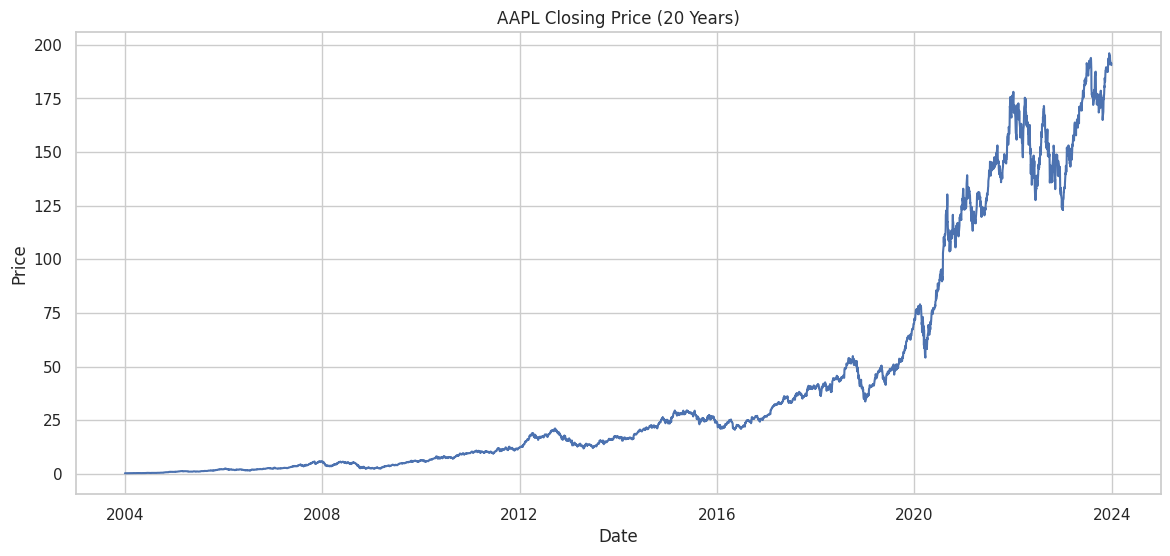

In [ ]:
# ============================================
# CELL 4: Visualize Stock Price
# ============================================

plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title(f"{ticker} Closing Price (20 Years)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [ ]:
# ============================================
# CELL 5: Select Features
# ============================================

features = ['Open', 'High', 'Low', 'Close', 'Volume']

data = df[features]

display(data.head())

Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2004-01-02,0.322851,0.325848,0.317308,0.318806,144642400
2004-01-05,0.320904,0.335435,0.320904,0.332140,395018400
2004-01-06,0.333338,0.335885,0.325249,0.330941,509348000
2004-01-07,0.331091,0.342028,0.328544,0.338432,586874400
2004-01-08,0.342177,0.355511,0.339331,0.349968,460303200


In [ ]:
# ============================================
# CELL 6: Normalize Data
# ============================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled Shape:", scaled_data.shape)

Scaled Shape: (5033, 5)


In [ ]:
# ============================================
# CELL 7: Create Rolling Sequences
# ============================================

sequence_length = 60

X = []
y = []

# Predict NEXT DAY closing price
for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])

    # Close price index = 3
    y.append(scaled_data[i, 3])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4973, 60, 5)
y Shape: (4973,)


In [ ]:
# ============================================
# CELL 8: Train-Test Split
# ============================================

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (3978, 60, 5)
Test Shape: (995, 60, 5)


In [ ]:
# ============================================
# CELL 9: Build CNN Model
# ============================================

model = Sequential()

# 1D CNN Layer
model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Pooling
model.add(MaxPooling1D(pool_size=2))

# Prevent Overfitting
model.add(Dropout(0.2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(50, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,925 (366.89 KB)

 Trainable params: 93,925 (366.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# CELL 10: Train Model
# ============================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.0476e-04 - val_loss: 0.0029
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4970e-04 - val_loss: 0.0020
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0267e-04 - val_loss: 0.0015
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.1462e-05 - val_loss: 0.0013
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.4459e-05 - val_loss: 0.0012
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0976e-05 - val_loss: 0.0017
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.8786e-05 - val_loss: 0.0011
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4480e-05 - val_loss: 0.0014
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4586e-05 - val_loss: 0.0021
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6088e-05 - val_loss: 0.0073
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.1727e-05 - val_loss: 9.2908e-04
Epoc

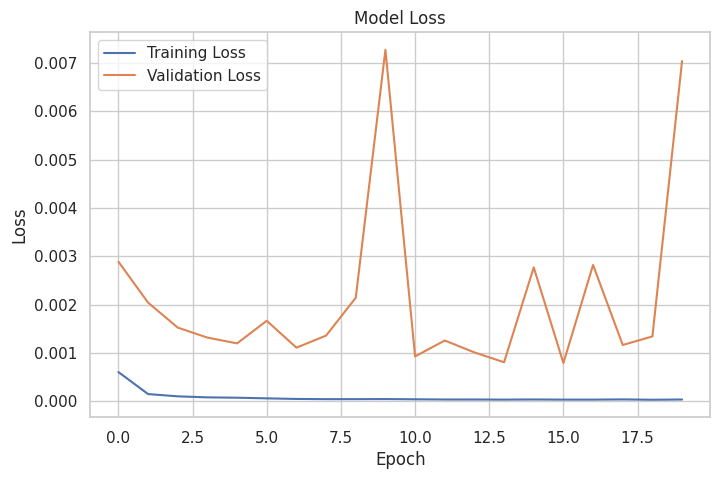

In [ ]:
# ============================================
# CELL 11: Plot Training Loss
# ============================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# ============================================
# CELL 12: Make Predictions
# ============================================

predictions = model.predict(X_test)

print(predictions[:5])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[0.40452713]
 [0.40758252]
 [0.40877116]
 [0.41139865]
 [0.41373667]]


In [ ]:
# ============================================
# CELL 13: Inverse Transform Predictions
# ============================================

# Create dummy arrays to inverse transform properly
dummy_pred = np.zeros((len(predictions), 5))
dummy_actual = np.zeros((len(y_test), 5))

# Close price index = 3
dummy_pred[:, 3] = predictions.flatten()
dummy_actual[:, 3] = y_test

predicted_prices = scaler.inverse_transform(dummy_pred)[:, 3]
actual_prices = scaler.inverse_transform(dummy_actual)[:, 3]

In [ ]:
# ============================================
# CELL 14: Evaluate Model
# ============================================

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

mae = mean_absolute_error(actual_prices, predicted_prices)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")

RMSE: 16.43
MAE : 14.74


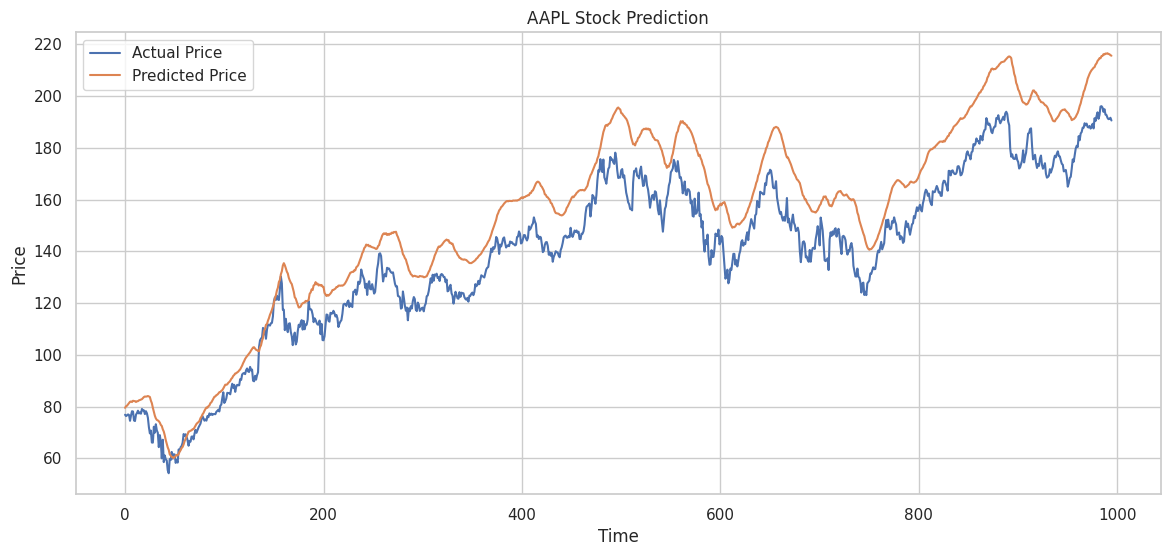

In [ ]:
# ============================================
# CELL 15: Visualize Predictions
# ============================================

plt.figure(figsize=(14,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.title(f"{ticker} Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()

In [ ]:
# ============================================
# CELL 16: Predict Next Day Price
# ============================================

last_sequence = scaled_data[-sequence_length:]

last_sequence = np.expand_dims(last_sequence, axis=0)

next_day_prediction = model.predict(last_sequence)

dummy_next = np.zeros((1, 5))
dummy_next[0, 3] = next_day_prediction

next_price = scaler.inverse_transform(dummy_next)[0, 3]

print(f"Predicted Next Day Closing Price: ${next_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Next Day Closing Price: $215.40


/tmp/ipykernel_2555/1631611842.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy_next[0, 3] = next_day_prediction
